# 03 - Wave Equation Experiments
**AC-PINN Project** | Authors: Suyash Vasal Jain, Nishita Raghvendra

**PDE:** $u_{tt} = c^2 u_{xx}$, $c = 1.0$

**IC:** $u(x,0) = \sin(\pi x)$, $u_t(x,0) = 0$ | **BC:** $u(-1,t) = u(1,t) = 0$

**Domain:** $x \in [-1,1]$, $t \in [0,1]$

**Architecture:** `[2, 64, 64, 64, 64, 64, 1]` | **Epochs:** 10000

**Note:** Wave equation is second-order in time - requires velocity IC.
Oscillatory nature makes it sensitive to sparse data.

In [1]:
import sys, os
sys.path.append('..')
import torch
import numpy as np
import matplotlib.pyplot as plt
from pinn_base import (
    device, NoisyDataGenerator, PINNSolver, ACPINNSolver,
    WaveFDM, Benchmark, save_metrics, save_history, save_training_plots
)

PDE        = 'wave'
LAYERS     = [2, 64, 64, 64, 64, 64, 1]
EPOCHS     = 10000
PDE_PARAMS = {'c': 1.0}
RESULTS    = '../results/wave/'
FIGURES    = '../figures/wave/'
os.makedirs(RESULTS, exist_ok=True)
os.makedirs(FIGURES, exist_ok=True)

gen = NoisyDataGenerator(pde=PDE, c=1.0)
print(f'Device: {device}')

Device: cuda


## Section 1 - FDM Ground Truth

WaveFDM solved in 0.0174s


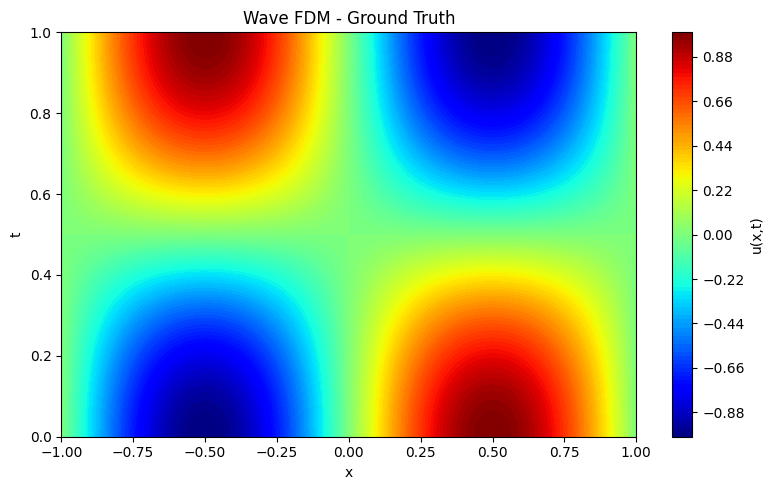

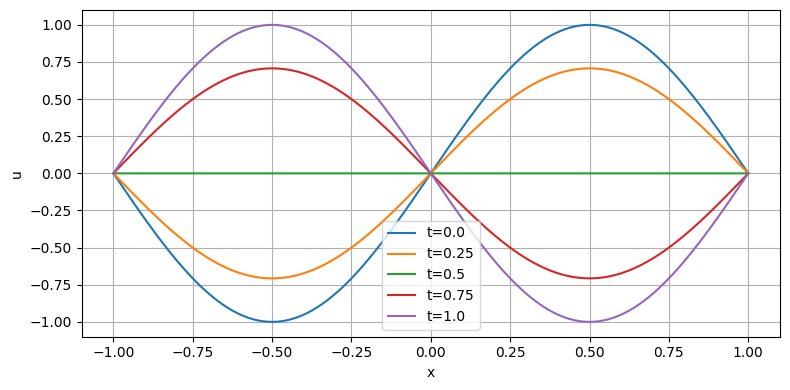

In [2]:
fdm = WaveFDM(nx=256, nt=2000, c=1.0)
fdm.solve()
fdm.plot_solution(title='Wave FDM - Ground Truth')
fdm.plot_time_slices()

## Section 2 - Data Conditions

In [3]:
data_clean_dense  = gen.generate(N_ic=1000, N_bc=1000, N_f=8000, noise_eps=0.0)
data_noisy_sparse = gen.generate(N_ic=20,   N_bc=20,   N_f=2000, noise_eps=0.1)
print('Data ready')
print(f'Wave data includes u_ic_dt: {"u_ic_dt" in data_clean_dense}')

Data ready
Wave data includes u_ic_dt: True


## Section 3 - Vanilla PINN, Clean Dense

D:\PINN\ac-pinn-project\ac-pinn-project\venv\Lib\site-packages\torch\autograd\graph.py:825: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:135.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


[Wave | Vanilla Clean | Epoch     0/10000] Total: 0.692259 | IC: 0.568879 | BC: 0.038519 | PDE: 0.016972


[Wave | Vanilla Clean | Epoch  1000/10000] Total: 0.037217 | IC: 0.012996 | BC: 0.023321 | PDE: 0.000180


[Wave | Vanilla Clean | Epoch  2000/10000] Total: 0.016579 | IC: 0.007023 | BC: 0.005491 | PDE: 0.000813


[Wave | Vanilla Clean | Epoch  3000/10000] Total: 0.009266 | IC: 0.001869 | BC: 0.002201 | PDE: 0.001039


...

[Wave | Vanilla Clean | Epoch  6000/10000] Total: 0.005923 | IC: 0.001578 | BC: 0.003318 | PDE: 0.000206


[Wave | Vanilla Clean | Epoch  7000/10000] Total: 0.000171 | IC: 0.000044 | BC: 0.000025 | PDE: 0.000020


[Wave | Vanilla Clean | Epoch  8000/10000] Total: 0.001989 | IC: 0.000236 | BC: 0.000479 | PDE: 0.000255


[Wave | Vanilla Clean | Epoch  9000/10000] Total: 0.000152 | IC: 0.000041 | BC: 0.000023 | PDE: 0.000017



Training complete in 206.37s


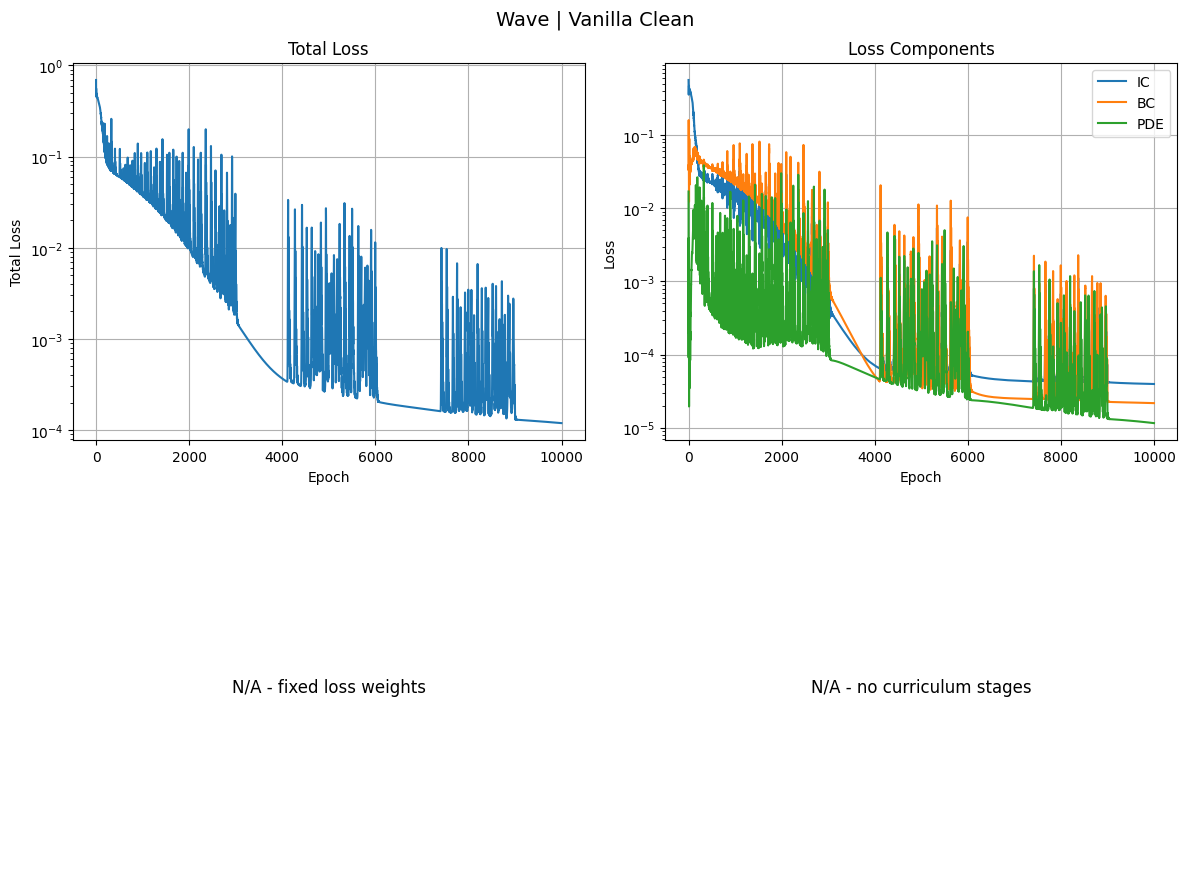

Saved: ../figures/wave/vanilla_clean_training.png
Saved: ../figures/wave/vanilla_clean_training.csv


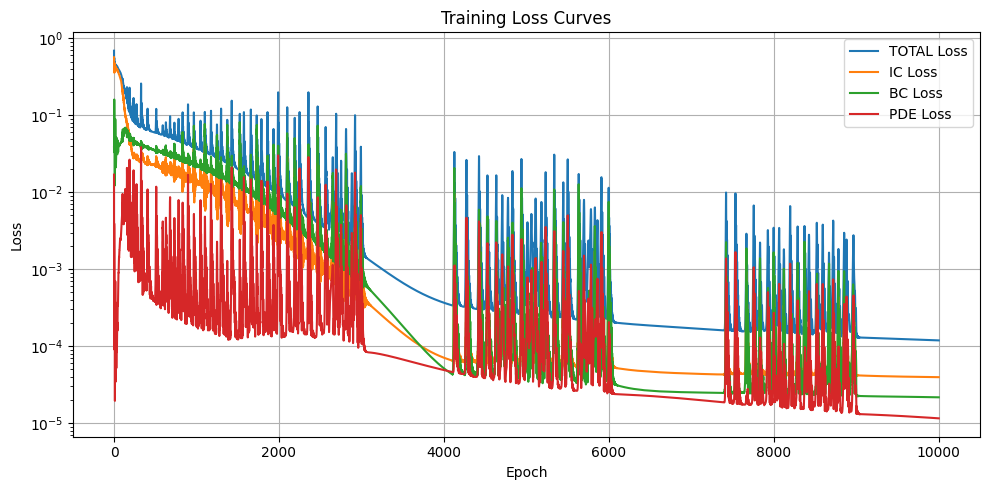

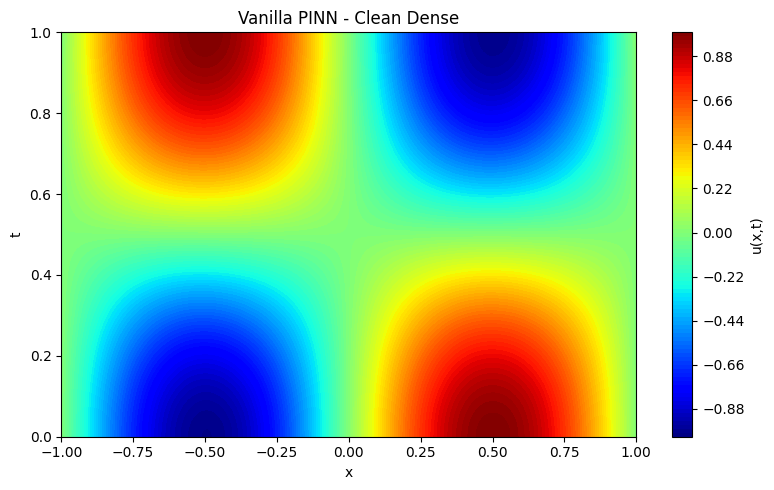

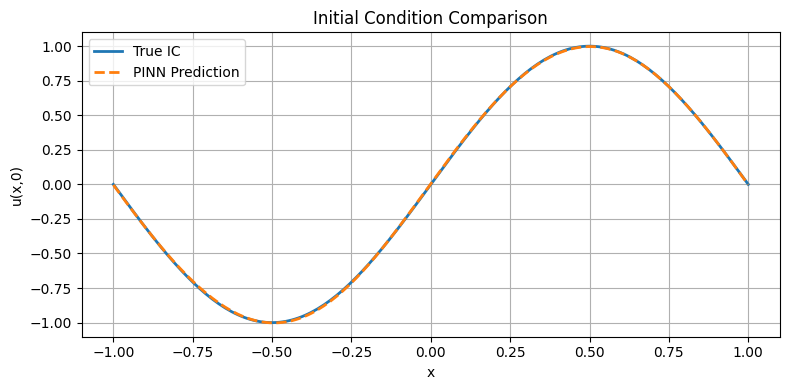

Saved: ../results/wave/vanilla_clean_history.npy


In [4]:
vanilla_clean = PINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS)
h_vc = vanilla_clean.fit(data_clean_dense, epochs=EPOCHS, print_every=1000, label='Wave | Vanilla Clean')
save_training_plots(h_vc, FIGURES+'vanilla_clean_training.png', 'Wave | Vanilla Clean')
vanilla_clean.plot_loss_history(h_vc)
vanilla_clean.plot_solution(title='Vanilla PINN - Clean Dense')
vanilla_clean.plot_initial_condition_comparison(gen)
save_history(h_vc, RESULTS+'vanilla_clean_history.npy')

## Section 4 - Vanilla PINN, Noisy Sparse

[Wave | Vanilla Noisy | Epoch     0/10000] Total: 0.800571 | IC: 0.728402 | BC: 0.063488 | PDE: 0.001736


[Wave | Vanilla Noisy | Epoch  1000/10000] Total: 0.065260 | IC: 0.022804 | BC: 0.040943 | PDE: 0.000303


[Wave | Vanilla Noisy | Epoch  2000/10000] Total: 0.037561 | IC: 0.014869 | BC: 0.020171 | PDE: 0.000504


[Wave | Vanilla Noisy | Epoch  3000/10000] Total: 0.030534 | IC: 0.010153 | BC: 0.012070 | PDE: 0.001662


[Wave | Vanilla Noisy | Epoch  4000/10000] Total: 0.021367 | IC: 0.009775 | BC: 0.011258 | PDE: 0.000067


...

[Wave | Vanilla Noisy | Epoch  6000/10000] Total: 0.021113 | IC: 0.009519 | BC: 0.011250 | PDE: 0.000069


[Wave | Vanilla Noisy | Epoch  7000/10000] Total: 0.020582 | IC: 0.009394 | BC: 0.011050 | PDE: 0.000027


[Wave | Vanilla Noisy | Epoch  8000/10000] Total: 0.021126 | IC: 0.009333 | BC: 0.010999 | PDE: 0.000159


[Wave | Vanilla Noisy | Epoch  9000/10000] Total: 0.020302 | IC: 0.009260 | BC: 0.010954 | PDE: 0.000018



Training complete in 185.42s


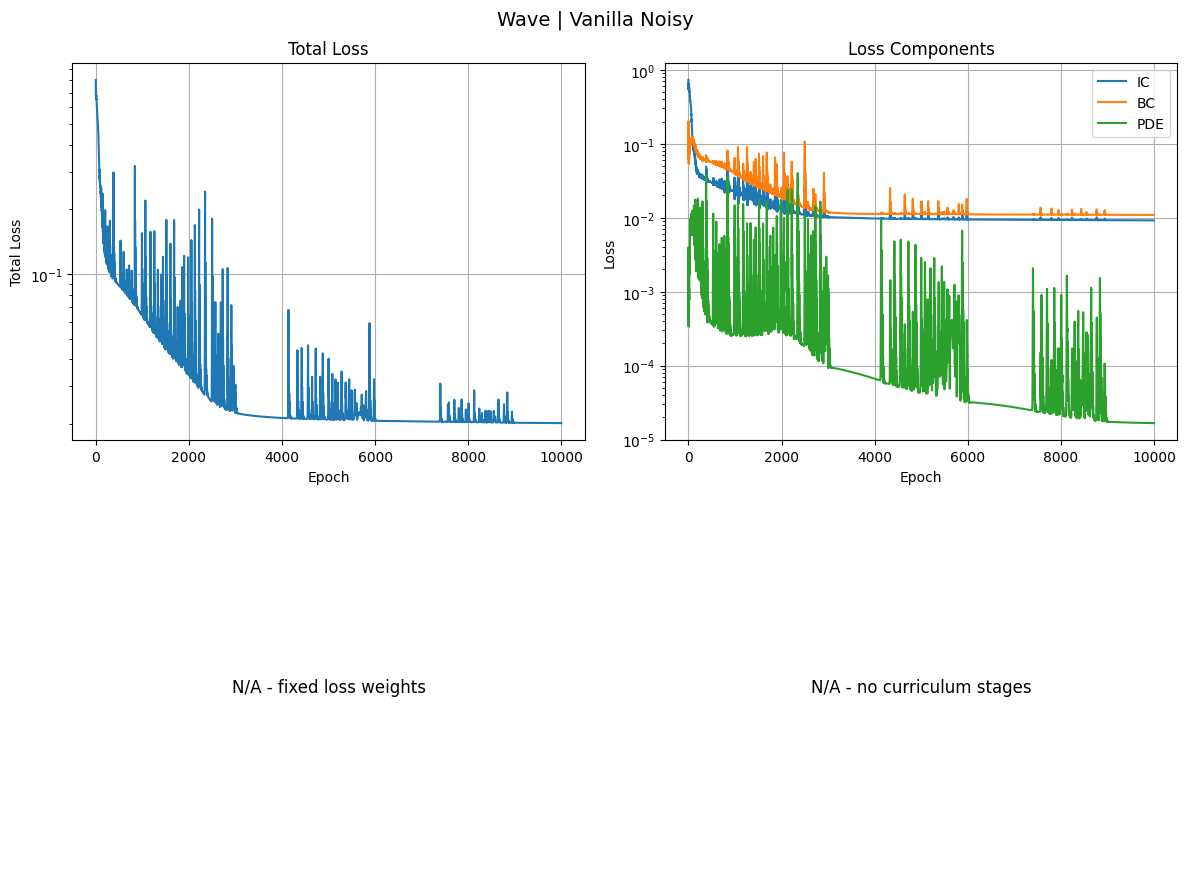

Saved: ../figures/wave/vanilla_noisy_training.png
Saved: ../figures/wave/vanilla_noisy_training.csv


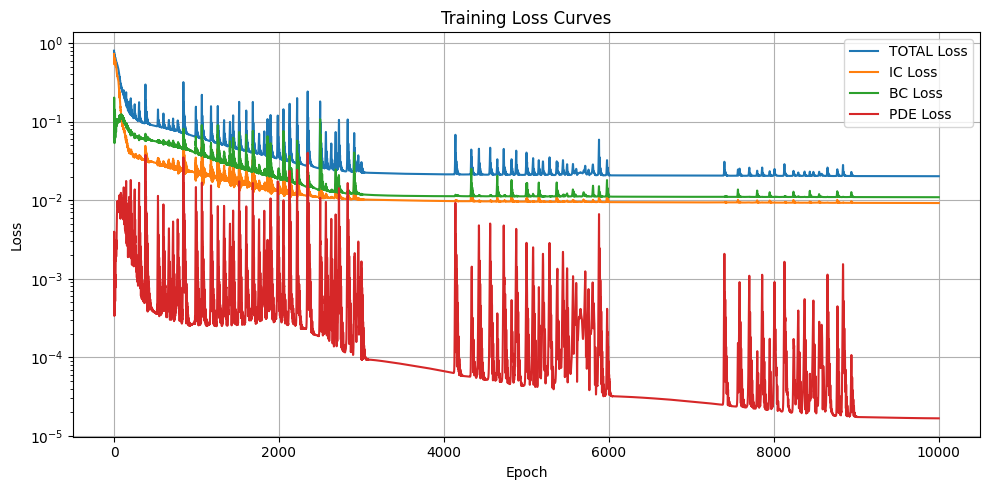

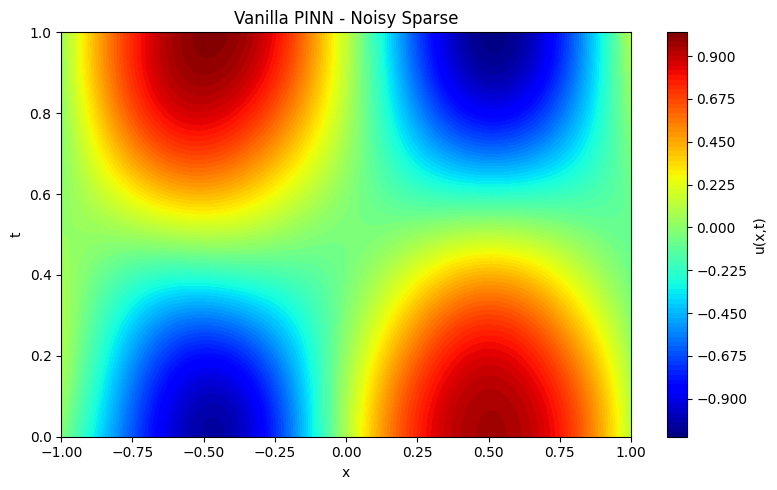

Saved: ../results/wave/vanilla_noisy_history.npy


In [5]:
vanilla_noisy = PINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS)
h_vn = vanilla_noisy.fit(data_noisy_sparse, epochs=EPOCHS, print_every=1000, label='Wave | Vanilla Noisy')
save_training_plots(h_vn, FIGURES+'vanilla_noisy_training.png', 'Wave | Vanilla Noisy')
vanilla_noisy.plot_loss_history(h_vn)
vanilla_noisy.plot_solution(title='Vanilla PINN - Noisy Sparse')
save_history(h_vn, RESULTS+'vanilla_noisy_history.npy')

## Section 5 - AC-PINN, Clean Dense

[Wave | AC-PINN Clean | Epoch     0/10000] Stage 1/4 | Total: 0.790404 | IC: 0.701415 | BC: 0.088407 | PDE: 0.000116 | lam=(1.00,1.00,5.00)


[Wave | AC-PINN Clean | Epoch  1000/10000] Stage 1/4 | Total: 0.074279 | IC: 0.022458 | BC: 0.013208 | PDE: 0.000324 | lam=(1.67,2.54,10.00)


[Wave | AC-PINN Clean | Epoch  2000/10000] Stage 1/4 | Total: 0.055801 | IC: 0.018303 | BC: 0.008601 | PDE: 0.000199 | lam=(1.51,3.04,10.00)


[Wave | AC-PINN Clean | Epoch  3000/10000] Stage 2/4 | Total: 0.038650 | IC: 0.014468 | BC: 0.004196 | PDE: 0.000144 | lam=(1.32,4.33,10.00)


[Wave | AC-PINN Clean | Epoch  4000/10000] Stage 2/4 | Total: 0.009757 | IC: 0.003376 | BC: 0.000880 | PDE: 0.000152 | lam=(1.34,4.22,10.00)


...

[Wave | AC-PINN Clean | Epoch  6000/10000] Stage 3/4 | Total: 0.002001 | IC: 0.000698 | BC: 0.000583 | PDE: 0.000706 | lam=(1.05,0.88,1.07)


[Wave | AC-PINN Clean | Epoch  7000/10000] Stage 3/4 | Total: 0.001283 | IC: 0.000331 | BC: 0.000397 | PDE: 0.000514 | lam=(0.80,0.96,1.24)


[Wave | AC-PINN Clean | Epoch  8000/10000] Stage 4/4 | Total: 0.155137 | IC: 0.058335 | BC: 0.007031 | PDE: 0.001458 | lam=(2.62,0.32,0.10)


[Wave | AC-PINN Clean | Epoch  9000/10000] Stage 4/4 | Total: 0.106783 | IC: 0.002402 | BC: 0.043160 | PDE: 0.009435 | lam=(0.13,2.35,0.51)



AC-PINN training complete in 219.96s


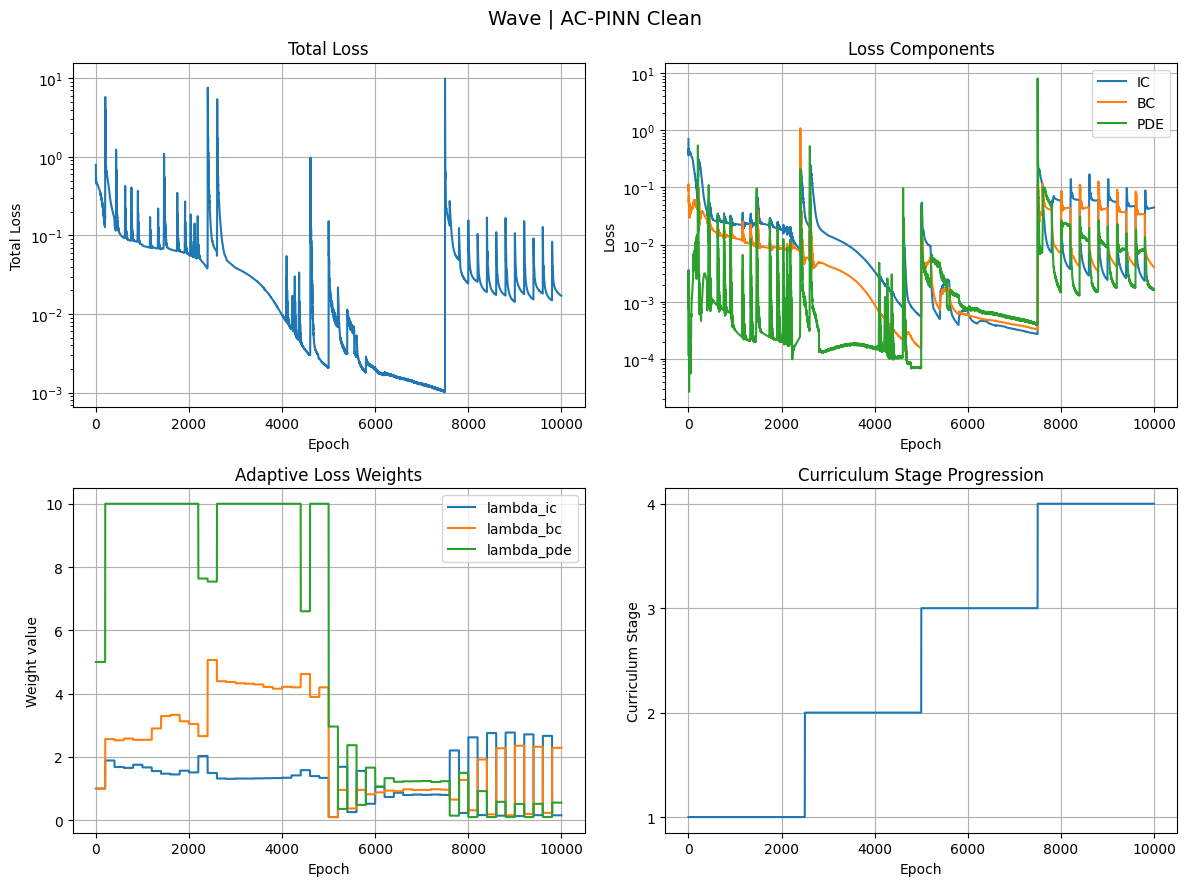

Saved: ../figures/wave/acpinn_clean_training.png
Saved: ../figures/wave/acpinn_clean_training.csv


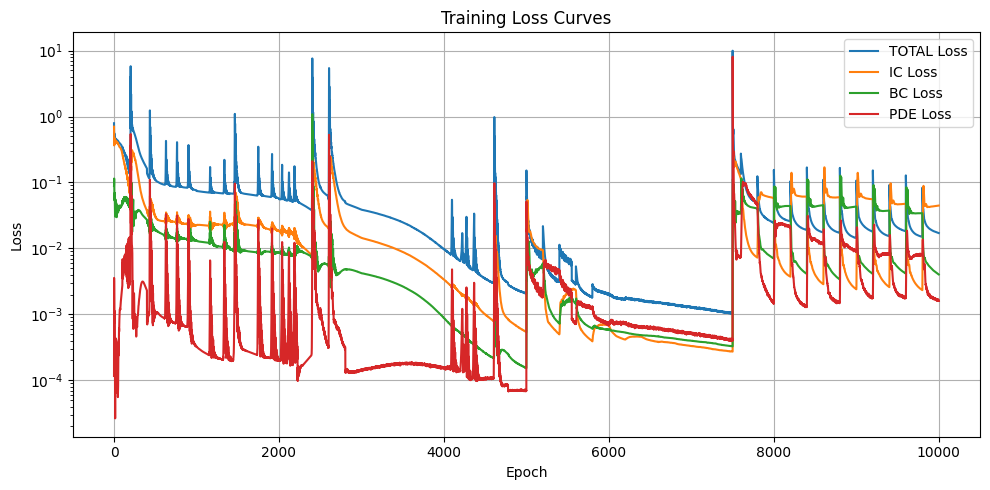

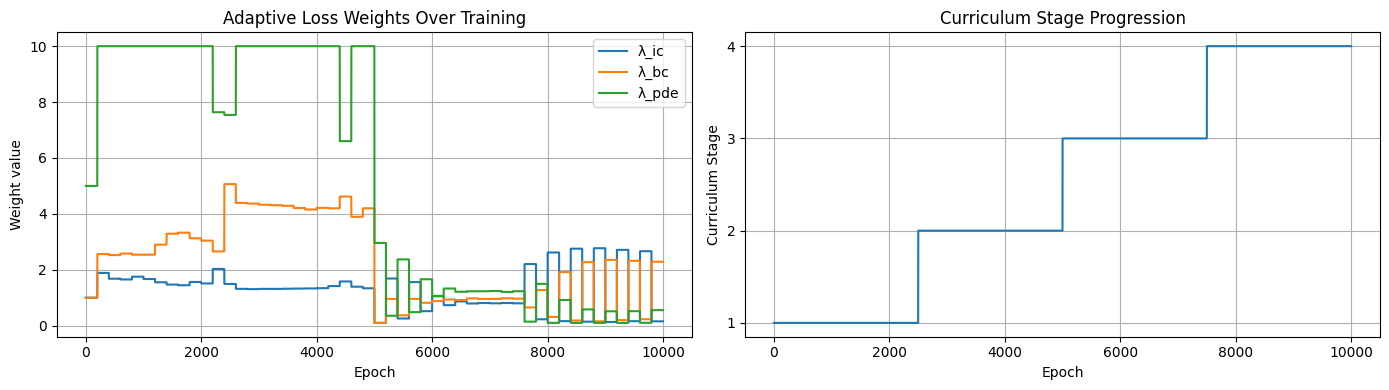

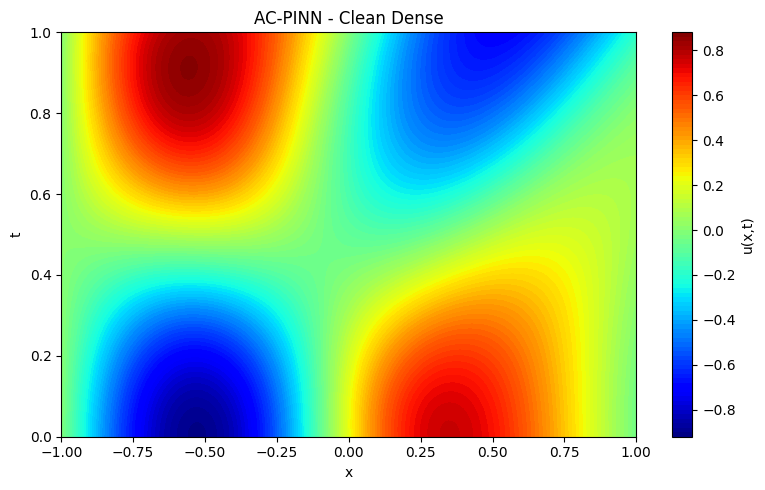

Saved: ../results/wave/ac_clean_history.npy


In [6]:
ac_clean = ACPINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS, weight_strategy='both')
h_ac = ac_clean.fit(data_clean_dense, epochs=EPOCHS, print_every=1000, label='Wave | AC-PINN Clean')
save_training_plots(h_ac, FIGURES+'acpinn_clean_training.png', 'Wave | AC-PINN Clean')
ac_clean.plot_loss_history(h_ac)
ac_clean.plot_weight_history(h_ac)
ac_clean.plot_solution(title='AC-PINN - Clean Dense')
save_history(h_ac, RESULTS+'ac_clean_history.npy')

## Section 6 - AC-PINN, Noisy Sparse

[Wave | AC-PINN Noisy | Epoch     0/10000] Stage 1/4 | Total: 0.793027 | IC: 0.763933 | BC: 0.028287 | PDE: 0.000161 | lam=(1.00,1.00,5.00)


[Wave | AC-PINN Noisy | Epoch  1000/10000] Stage 1/4 | Total: 0.114295 | IC: 0.014918 | BC: 0.023564 | PDE: 0.000713 | lam=(1.90,3.49,5.39)


[Wave | AC-PINN Noisy | Epoch  2000/10000] Stage 1/4 | Total: 0.526019 | IC: 0.155169 | BC: 0.095617 | PDE: 0.002542 | lam=(1.72,2.45,10.00)


[Wave | AC-PINN Noisy | Epoch  3000/10000] Stage 2/4 | Total: 0.098739 | IC: 0.019429 | BC: 0.017525 | PDE: 0.000457 | lam=(1.40,3.82,10.00)


[Wave | AC-PINN Noisy | Epoch  4000/10000] Stage 2/4 | Total: 0.096460 | IC: 0.011746 | BC: 0.011591 | PDE: 0.000787 | lam=(4.01,4.13,1.97)


...

[Wave | AC-PINN Noisy | Epoch  6000/10000] Stage 3/4 | Total: 0.028861 | IC: 0.009399 | BC: 0.011083 | PDE: 0.001810 | lam=(1.26,1.49,0.24)


[Wave | AC-PINN Noisy | Epoch  7000/10000] Stage 3/4 | Total: 0.028829 | IC: 0.009274 | BC: 0.010977 | PDE: 0.001460 | lam=(1.28,1.52,0.20)


[Wave | AC-PINN Noisy | Epoch  8000/10000] Stage 4/4 | Total: 0.143092 | IC: 0.024540 | BC: 0.036471 | PDE: 0.063174 | lam=(0.59,0.88,1.53)


[Wave | AC-PINN Noisy | Epoch  9000/10000] Stage 4/4 | Total: 0.084809 | IC: 0.027939 | BC: 0.029697 | PDE: 0.001259 | lam=(1.42,1.51,0.10)



AC-PINN training complete in 198.76s


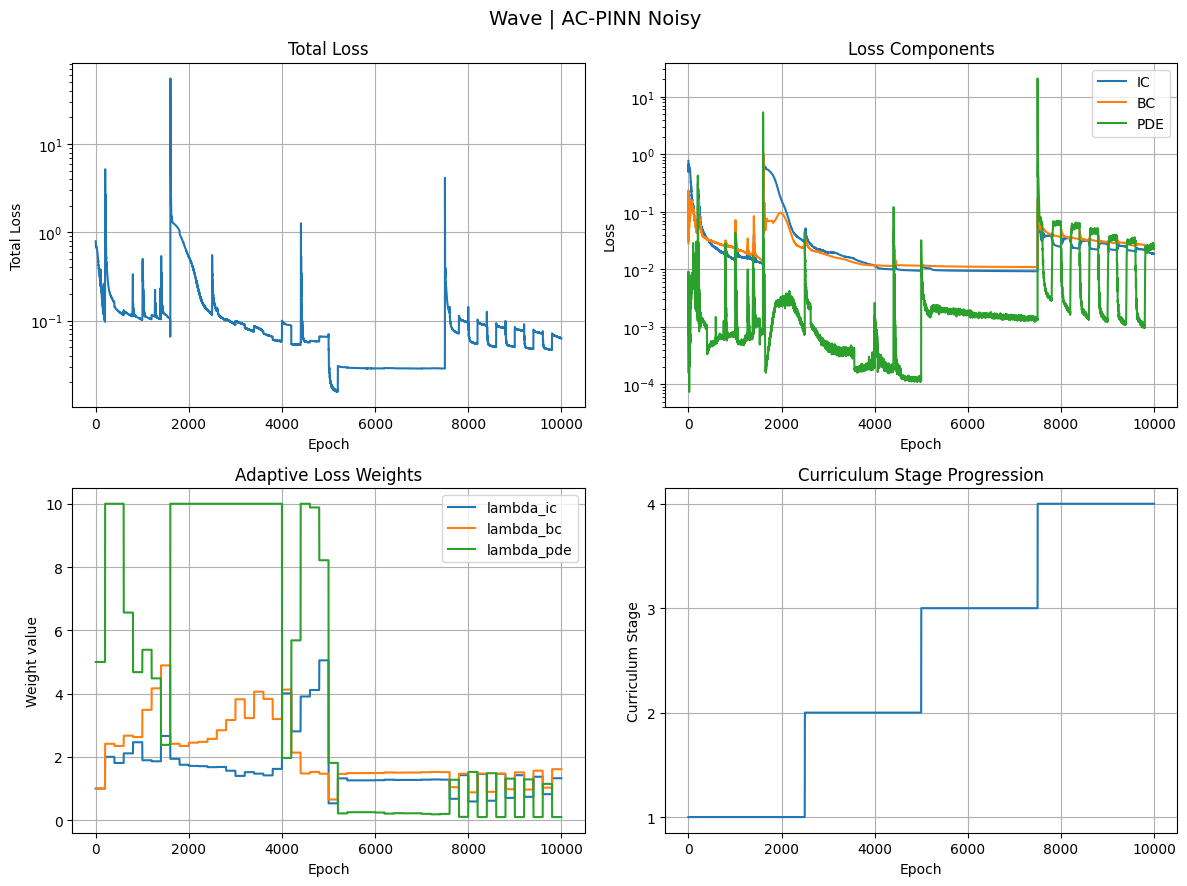

Saved: ../figures/wave/acpinn_noisy_training.png
Saved: ../figures/wave/acpinn_noisy_training.csv


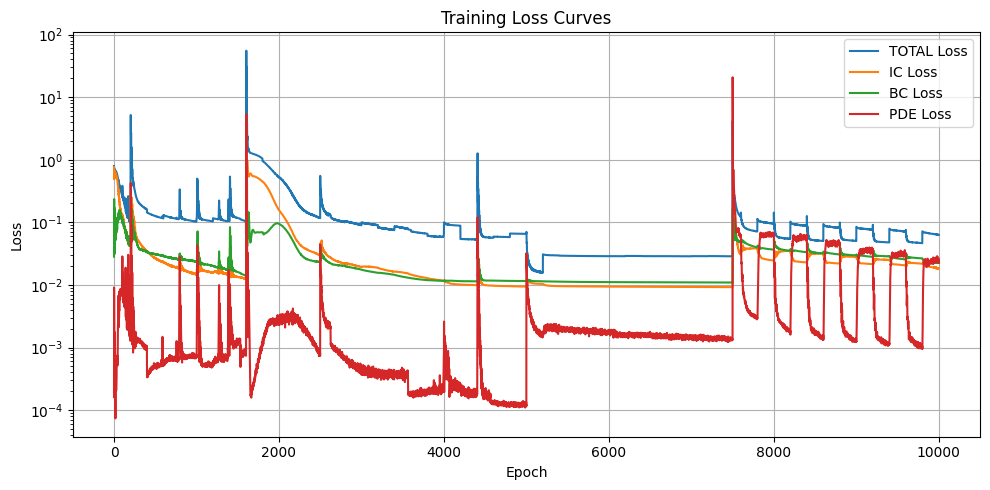

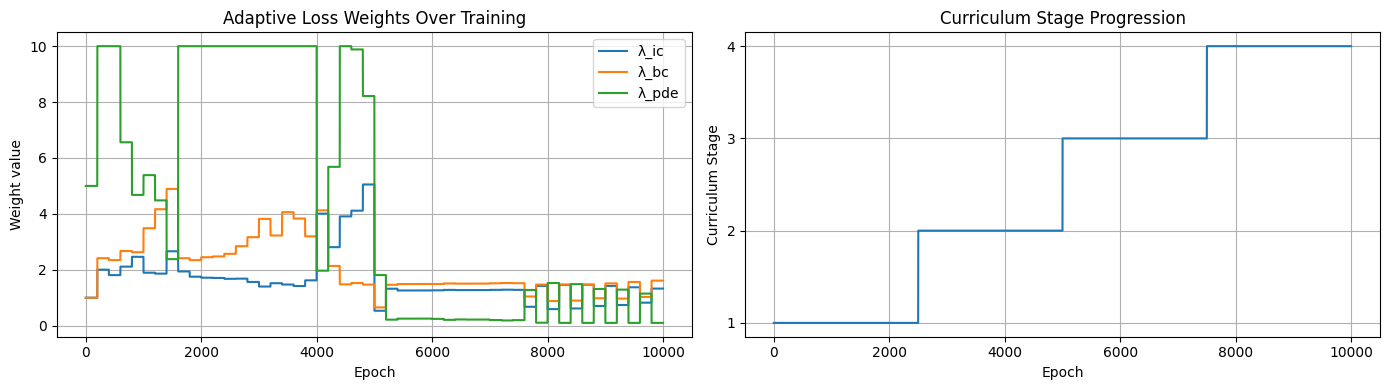

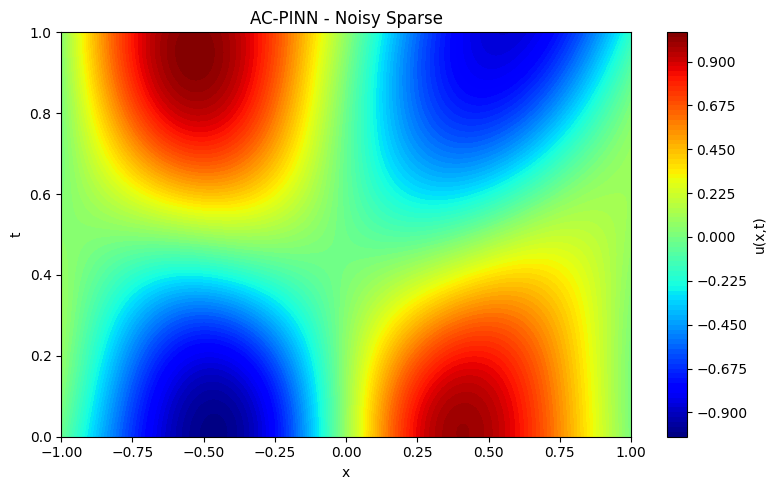

Saved: ../results/wave/ac_noisy_history.npy


In [7]:
ac_noisy = ACPINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS, weight_strategy='both')
h_an = ac_noisy.fit(data_noisy_sparse, epochs=EPOCHS, print_every=1000, label='Wave | AC-PINN Noisy')
save_training_plots(h_an, FIGURES+'acpinn_noisy_training.png', 'Wave | AC-PINN Noisy')
ac_noisy.plot_loss_history(h_an)
ac_noisy.plot_weight_history(h_an)
ac_noisy.plot_solution(title='AC-PINN - Noisy Sparse')
save_history(h_an, RESULTS+'ac_noisy_history.npy')

## Section 7 - Benchmark vs FDM

  Model                         Rel L2    Max Err        MAE       RMSE
  Vanilla (clean)             0.017337   0.021883   0.006808   0.008646
  Vanilla (noisy)             0.118664   0.135957   0.049845   0.059180
  AC-PINN (clean)             0.302694   0.395651   0.120278   0.150959
  AC-PINN (noisy)             0.168101   0.222303   0.068520   0.083835


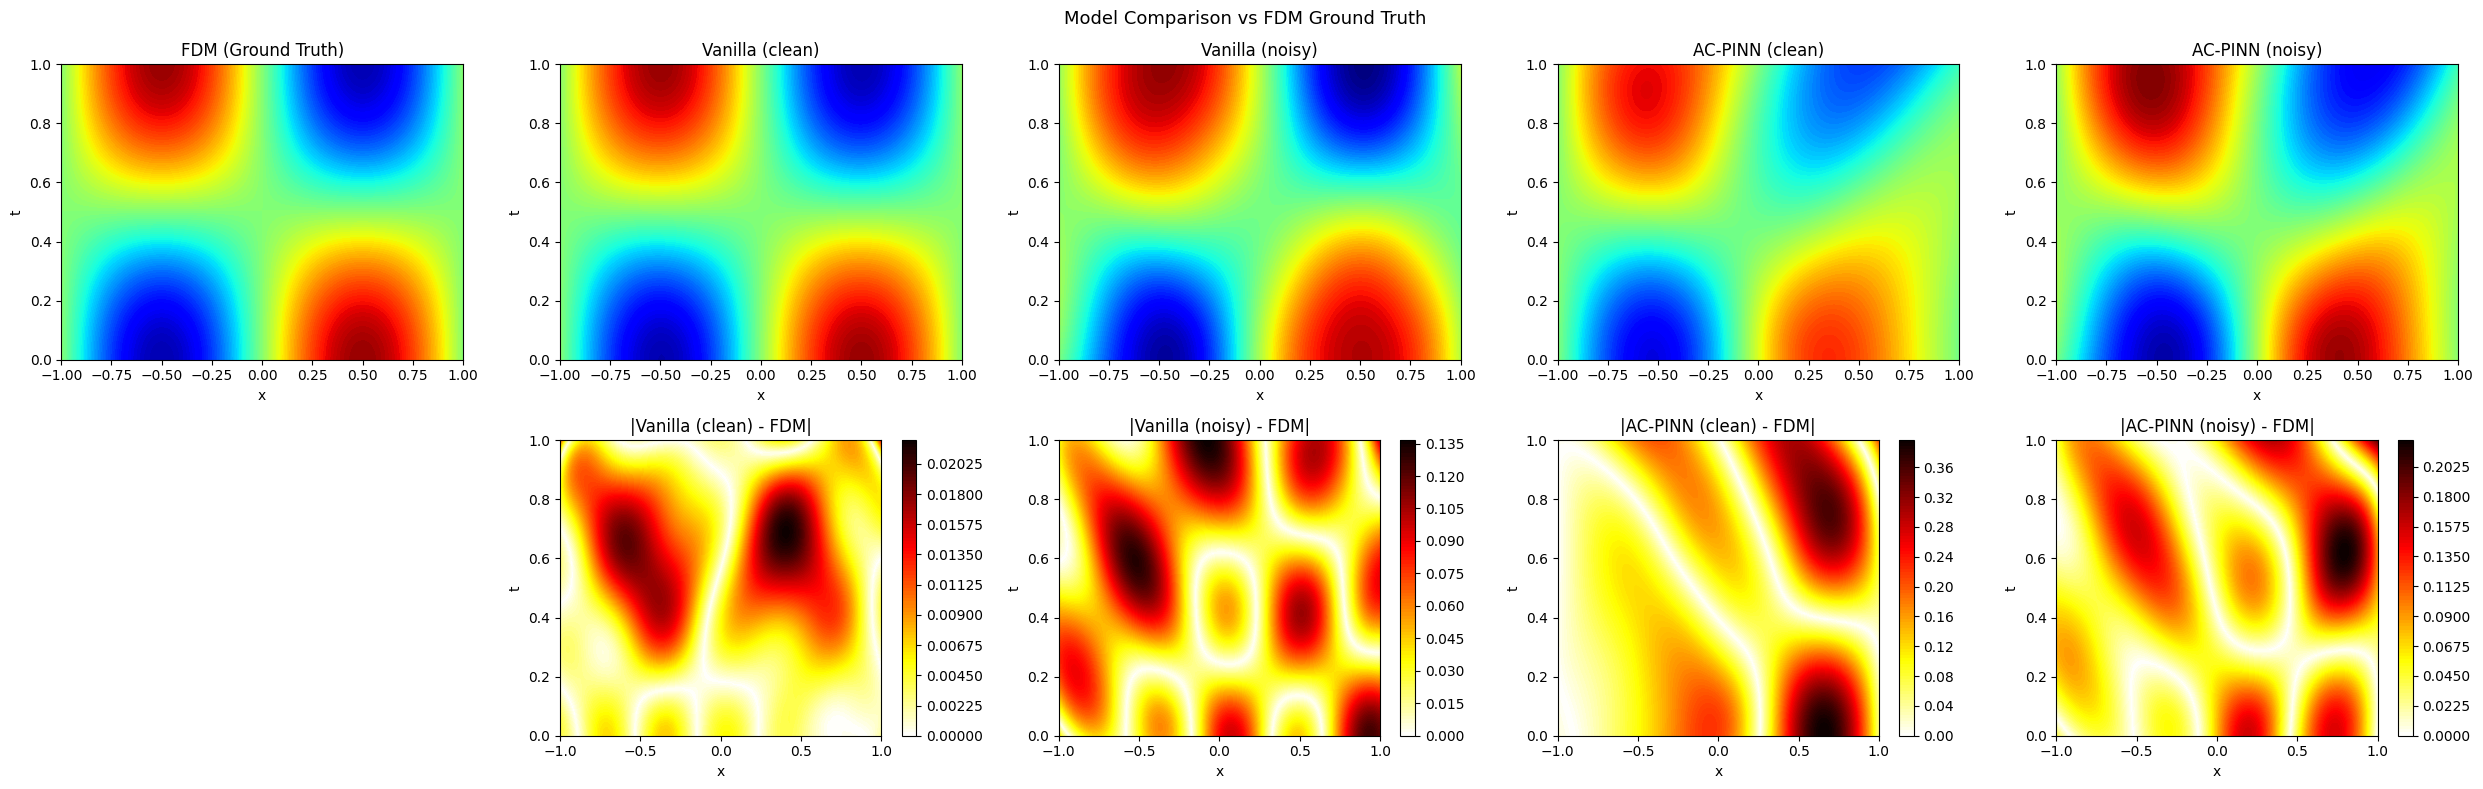

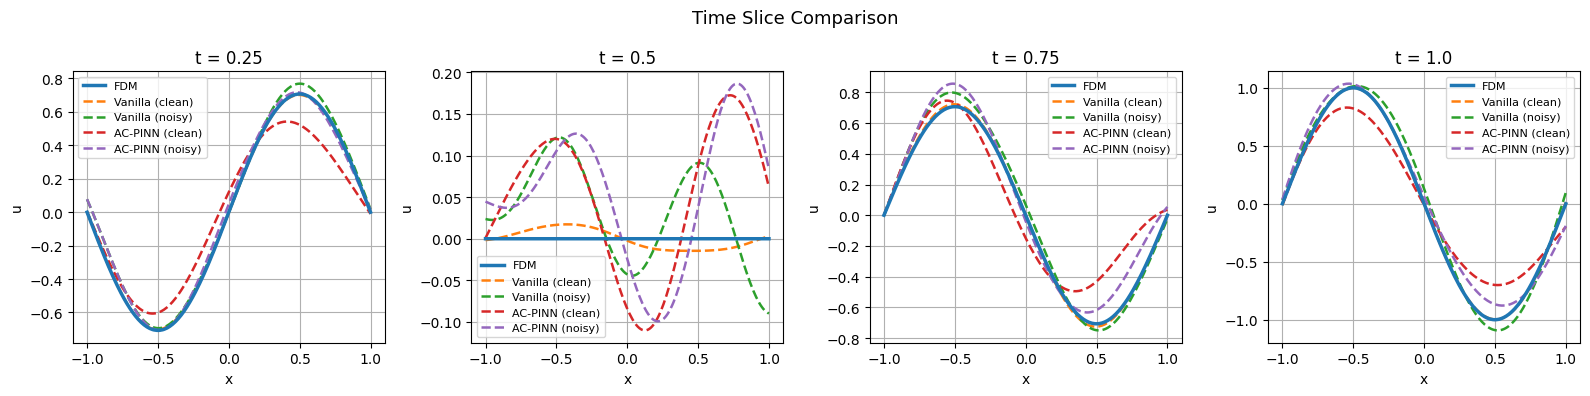

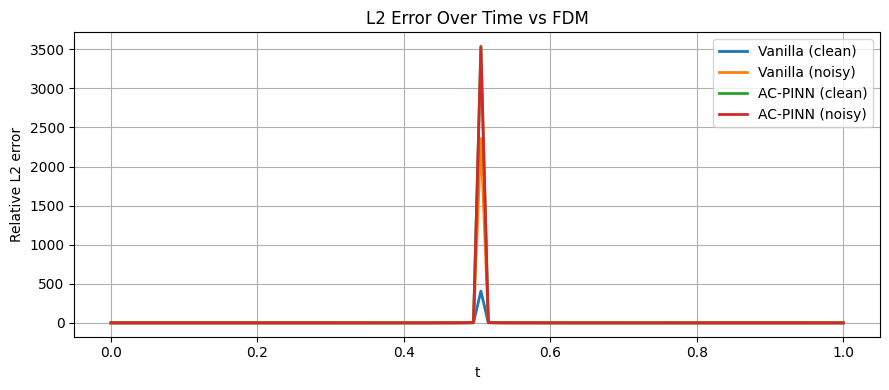

Saved: ../results/wave/benchmark_metrics.npy
Wave experiments complete.


In [8]:
bench = Benchmark(fdm, nx=200, nt=100)
bench.add('Vanilla (clean)', vanilla_clean)
bench.add('Vanilla (noisy)', vanilla_noisy)
bench.add('AC-PINN (clean)', ac_clean)
bench.add('AC-PINN (noisy)', ac_noisy)
bench.run()

metrics = bench.compare_metrics()
bench.plot_comparison(save_path=FIGURES+'comparison.png')
bench.plot_time_slices(save_path=FIGURES+'time_slices.png')
bench.plot_error_over_time(save_path=FIGURES+'error_over_time.png')

save_metrics(metrics, RESULTS+'benchmark_metrics.npy')
print('Wave experiments complete.')

## Section 8 - Noise Level Study

In [9]:
noise_results = {}
for eps in [0.05, 0.1, 0.2]:
    print(f'\n--- ε={eps} ---')
    d = gen.generate(N_ic=50, N_bc=50, N_f=3000, noise_eps=eps)
    v = PINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS)
    v.fit(d, epochs=5000, print_every=2500)
    a = ACPINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS, weight_strategy='both')
    a.fit(d, epochs=5000, print_every=2500)
    b = Benchmark(fdm).add(f'Vanilla ε={eps}', v).add(f'AC-PINN ε={eps}', a)
    b.run()
    noise_results[eps] = b.compare_metrics()
save_metrics(noise_results, RESULTS+'noise_study_metrics.npy')


--- ε=0.05 ---
[Epoch     0/5000] Total: 0.482723 | IC: 0.464895 | BC: 0.007558 | PDE: 0.002054


[Epoch  2500/5000] Total: 0.027939 | IC: 0.009492 | BC: 0.010849 | PDE: 0.001520



Training complete in 93.18s
[Epoch     0/5000] Stage 1/4 | Total: 0.898607 | IC: 0.762293 | BC: 0.121821 | PDE: 0.002898 | lam=(1.00,1.00,5.00)


[Epoch  2500/5000] Stage 3/4 | Total: 0.164577 | IC: 0.035415 | BC: 0.012434 | PDE: 0.005596 | lam=(1.44,5.14,8.86)



AC-PINN training complete in 100.52s
  Model                         Rel L2    Max Err        MAE       RMSE
  Vanilla ε=0.05              0.067862   0.085063   0.029349   0.033844
  AC-PINN ε=0.05              0.078829   0.095128   0.031831   0.039313

--- ε=0.1 ---
[Epoch     0/5000] Total: 0.557114 | IC: 0.486784 | BC: 0.066896 | PDE: 0.000687


...


AC-PINN training complete in 100.16s
  Model                         Rel L2    Max Err        MAE       RMSE
  Vanilla ε=0.1               0.166502   0.251266   0.069154   0.083037
  AC-PINN ε=0.1               0.137920   0.228018   0.050743   0.068783

--- ε=0.2 ---
[Epoch     0/5000] Total: 0.928251 | IC: 0.763331 | BC: 0.127588 | PDE: 0.007466


[Epoch  2500/5000] Total: 0.119729 | IC: 0.072290 | BC: 0.046998 | PDE: 0.000088



Training complete in 93.77s
[Epoch     0/5000] Stage 1/4 | Total: 0.679466 | IC: 0.624233 | BC: 0.052713 | PDE: 0.000504 | lam=(1.00,1.00,5.00)


[Epoch  2500/5000] Stage 3/4 | Total: 0.412775 | IC: 0.074632 | BC: 0.045745 | PDE: 0.014845 | lam=(2.23,4.39,3.10)



AC-PINN training complete in 100.07s
  Model                         Rel L2    Max Err        MAE       RMSE
  Vanilla ε=0.2               0.139454   0.167678   0.054729   0.069548
  AC-PINN ε=0.2               0.112528   0.146996   0.046122   0.056120
Saved: ../results/wave/noise_study_metrics.npy
